# LLM Instruction Tuning (지시 기반 미세조정)

- **Instruction(지시)**: 모델이 수행해야 하는 작업이다.
- **Context/Input(문맥)**: 작업을 수행하는 데 필요한 추가 정보다.
- **Response/Completion(응답)**: 모델이 생성하도록 학습할 정답 부분이다.

이 실습에서는 CodeAlpaca 데이터를 사용하고, `facebook/opt-350m`에 LoRA를 적용한다. 학습 손실은 prompt가 아니라 **completion 토큰에만 계산**하도록 구성한다.


<a id="setup"></a>
# 환경 설정

## 라이브러리 설치

- `trl==1.9.0`
- `transformers==5.14.1`
- `peft==0.19.1`
- `datasets==5.0.0`
- `accelerate==1.14.0`


In [1]:
%%time

!pip uninstall -y torchao

%pip install -q -U \
  "trl==1.9.0" \
  "transformers==5.14.1" \
  "peft==0.19.1" \
  "datasets==5.0.0" \
  "accelerate==1.14.0"

%pip install -q -U evaluate sacrebleu

import torch, trl, transformers, peft, datasets

print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

print("trl:", trl.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("datasets:", datasets.__version__)


Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 885.0/885.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 6.1 MB/s eta 0:00:00
PyTorch: 2.11.0+cu128
CUDA 사용 가능: True
GPU: Tesla T4
CUDA: 12.8
trl: 1.9.0
transformers: 5.14.1
peft: 0.19.1
datasets: 5.0.0
CPU times: user 16.4 s, sys: 2.4 s, total: 18.8 s
Wall time: 1min 9s


### 필요한 라이브러리 임포트

아래 코드는 필요한 라이브러리들을 임포트한다.

In [2]:
import io
import json
import pickle
import warnings
from urllib.request import urlopen

import evaluate
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from peft import LoraConfig, TaskType, get_peft_model
from torch.utils.data import Dataset
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from trl import SFTConfig, SFTTrainer

warnings.filterwarnings("ignore")


### 디바이스 정의

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pipeline_device = 0 if torch.cuda.is_available() else -1

print("사용 디바이스:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


사용 디바이스: cuda
GPU: Tesla T4


# 데이터셋 설명

아래 코드로 프로그래밍 코드 데이터셋인 **CodeAlpaca 20k** 데이터셋을 다운로드한다. 이 데이터는 [여기](https://github.com/sahil280114/codealpaca?tab=readme-ov-file#data-release)에서 확인할 수 있다. CodeAlpaca 데이터셋은 다음 요소로 구성된다:

- `instruction`: **str**, 모델이 수행해야 할 작업을 설명한다. 2만 개의 지시는 각각 고유하다.
- `input`: **str**, 작업에 대한 선택적 문맥 또는 입력이다. 예를 들어 지시가 "다음 SQL 쿼리를 distinct 요소를 선택하도록 수정하라"인 경우, input은 해당 SQL 쿼리가 된다. 전체 예시의 약 40%가 input을 가지고 있다.
- `output`: **str**, text-davinci-003이 생성한 지시에 대한 답변이다.

아래 코드 블록은 CodeAlpaca-20k 데이터셋을 `json` 파일로 다운로드한다:

In [4]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/WzOT_CwDALWedTtXjwH7bA/CodeAlpaca-20k.json

--2026-08-07 10:55:55--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/WzOT_CwDALWedTtXjwH7bA/CodeAlpaca-20k.json
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6957007 (6.6M) [application/json]
Saving to: ‘CodeAlpaca-20k.json’

CodeAlpaca-20k.json 100%[===================>]   6.63M  3.51MB/s    in 1.9s    

2026-08-07 10:55:59 (3.51 MB/s) - ‘CodeAlpaca-20k.json’ saved [6957007/6957007]



다음으로 데이터셋을 불러옵니다:

In [5]:
dataset = load_dataset("json", data_files="CodeAlpaca-20k.json", split="train")
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['output', 'instruction', 'input'],
    num_rows: 20022
})

데이터셋의 예시를 하나 살펴본다:

In [6]:
dataset[1000]

{'output': 's = "Hello world" \ns = s[::-1] \nprint(s)',
 'instruction': 'Reverse the string given in the input',
 'input': 'Hello world'}

단순화를 위해, `input`이 없는 예시들만 사용한다:

In [7]:
dataset = dataset.filter(lambda example: example["input"] == '')

Filter:   0%|          | 0/20022 [00:00<?, ? examples/s]

원본 CodeAlpaca 데이터셋은 섞여(shuffle) 있지 않을 수 있다. 아래는 랜덤 시드를 사용해 `datasets.arrow_dataset.Dataset()` 객체를 섞는 방법이다:

In [8]:
dataset = dataset.shuffle(seed=42)

In [9]:
dataset

Dataset({
    features: ['output', 'instruction', 'input'],
    num_rows: 9764
})

CodeAlpaca 20k 데이터셋에는 학습 세트와 테스트 세트가 있다. 원본 학습 데이터를 80%는 학습 세트, 20%는 테스트 세트로 나눌 수 있다.

In [10]:
dataset_split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = dataset_split['train']
test_dataset = dataset_split['test']
dataset_split

DatasetDict({
    train: Dataset({
        features: ['output', 'instruction', 'input'],
        num_rows: 7811
    })
    test: Dataset({
        features: ['output', 'instruction', 'input'],
        num_rows: 1953
    })
})

리소스 제약을 고려해, 평가용으로 작은 데이터 집합을 선택한다. (이 데이터는 학습이 아닌 평가 부분에서만 사용된다.)

In [11]:
# 리소스 제약을 위한 소규모 데이터 선택
tiny_test_dataset = test_dataset.select(range(10))
tiny_train_dataset = train_dataset.select(range(10))

# 모델과 토크나이저

이 실습에서는 Facebook의 [`opt-350m`](https://huggingface.co/facebook/opt-350m) 모델을 미세조정한다. 이 오픈소스 모델에 대한 설명은 [여기](https://arxiv.org/abs/2205.01068)에 발표되어 있으며, 모델은 [metaseq의 Github 저장소](https://github.com/facebookresearch/metaseq)에서 처음 공개되었다.

아래 코드는 Hugging Face에서 베이스 모델을 불러온다:

In [12]:
# 베이스 모델
model = AutoModelForCausalLM.from_pretrained("facebook/opt-350m").to(device)

config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  663MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

이 모델은 자체 토크나이저를 함께 제공하며, 여기서 불러온다:

In [13]:
tokenizer = AutoTokenizer.from_pretrained("facebook/opt-350m", padding_side='left')

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

문장의 끝(EOS, end of sentence) 토큰을 확인해 본다. 이는 특수 토크나이저 토큰으로, 이 토큰이 나타나면 모델은 더 이상 토큰을 생성하지 않고 멈춘다:

In [14]:
tokenizer.eos_token

'</s>'

# 데이터 전처리

미세조정을 위해 데이터를 전처리한다. 여기서는 두 가지를 준비한다.

1. **평가용 프롬프트 생성 함수** — 베이스/미세조정 모델에 넣을 입력(응답 제외)과, 비교 대상인 기대 응답(`expected_outputs`)을 만든다.
2. **학습용 prompt-completion 데이터셋** — 최신 `trl`의 `SFTTrainer`는 `prompt`/`completion` 두 컬럼을 가진 데이터셋을 받으면, 프롬프트 토큰은 손실에서 자동으로 무시(마스킹)하고 **completion(응답) 토큰에 대해서만 손실을 계산**한다. 예전처럼 `DataCollatorForCompletionOnlyLM`을 따로 만들 필요가 없다.

먼저 프롬프트 형식을 정의한다. 아래 형식을 사용한다:

```
### Instruction:
Translate the following sentence to Spanish: "Hello, how are you?"

### Response:
"Hola, ¿cómo estás?"
```

`formatting_prompts_func`는 instruction과 output을 합쳐 전체 텍스트(응답 포함)를 만들고, `formatting_prompts_func_no_response`는 동일하지만 응답을 포함하지 않는다. (이 두 함수는 주로 **평가**에 사용된다.)

***참고:*** `### Response:`를 `### Output:`으로 바꿔도 비슷한 결과를 얻을 수 있다.

In [15]:
def formatting_prompts_func(mydataset):
    output_texts = []
    for i in range(len(mydataset['instruction'])):
        text = (
            f"### Instruction:\n{mydataset['instruction'][i]}"
            f"\n\n### Response:\n{mydataset['output'][i]}"
        )
        output_texts.append(text)
    return output_texts

def formatting_prompts_func_no_response(mydataset):
    output_texts = []
    for i in range(len(mydataset['instruction'])):
        text = (
            f"### Instruction:\n{mydataset['instruction'][i]}"
            f"\n\n### Response:\n"
        )
        output_texts.append(text)
    return output_texts

아래 코드 블록은 평가에 필요한 세 가지를 만든다: `instructions`(응답을 제외한 프롬프트), `instructions_with_responses`(응답을 포함한 전체 텍스트), 그리고 `expected_outputs`(둘 사이의 차이, 즉 기대 응답).

`expected_outputs`를 얻기 위해 `instructions`와 `instructions_with_responses`를 각각 토큰화하고, `instructions`의 토큰 길이만큼 앞부분을 잘라낸 나머지를 디코딩한다:

In [16]:
expected_outputs = []
instructions_with_responses = formatting_prompts_func(test_dataset)
instructions = formatting_prompts_func_no_response(test_dataset)
for i in tqdm(range(len(instructions_with_responses))):
    tokenized_instruction_with_response = tokenizer(instructions_with_responses[i], return_tensors="pt", max_length=1024, truncation=True, padding=False)
    tokenized_instruction = tokenizer(instructions[i], return_tensors="pt")
    response_ids = tokenized_instruction_with_response['input_ids'][0][len(tokenized_instruction['input_ids'][0]):]
    expected_output = tokenizer.decode(response_ids, skip_special_tokens=True)
    expected_outputs.append(expected_output)

100%|██████████| 1953/1953 [00:02<00:00, 731.98it/s]


`instructions`, `instructions_with_responses`, `expected_outputs`가 각각 무엇을 담고 있는지 예시로 확인해 본다:

In [17]:
print('############## instructions ##############\n' + instructions[0])
print('############## instructions_with_responses ##############\n' + instructions_with_responses[0])
print('\n############## expected_outputs ##############' + expected_outputs[0])

############## instructions ##############
### Instruction:
Name the most important benefit of using a database system.

### Response:

############## instructions_with_responses ##############
### Instruction:
Name the most important benefit of using a database system.

### Response:
The most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.

############## expected_outputs ##############The most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.


`instructions` 리스트를 그대로 두기보다, `torch`의 `Dataset` 객체로 변환하는 것이 유용하다. 아래 코드는 리스트로부터 `torch` `Dataset`을 만드는 `ListDataset` 클래스를 정의하고, 이를 사용해 `instructions`로부터 `Dataset` 객체를 생성한다:

In [18]:
class ListDataset(Dataset):
    def __init__(self, original_list):
        self.original_list = original_list

    def __len__(self):
        return len(self.original_list)

    def __getitem__(self, i):
        return self.original_list[i]

instructions_torch = ListDataset(instructions)

In [19]:
instructions_torch[0]

'### Instruction:\nName the most important benefit of using a database system.\n\n### Response:\n'

# 베이스 모델 테스트

미세조정 전, 베이스 모델(미세조정하지 않은 모델)이 어떻게 동작하는지 살펴본다.

아래 코드는 `transformers`의 `pipeline` 클래스를 사용해 텍스트 생성 파이프라인을 정의한다. 이 파이프라인은 주어진 모델과 토크나이저로 텍스트를 생성하는 데 유용한다:

In [20]:
gen_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=pipeline_device,
    batch_size=2,
    truncation=True,
    return_full_text=False,
)


***참고:*** 생성 파이프라인은 토큰 또는 텍스트를 생성할 수 있다. `return_tensors=True`이면 토큰 ID를 반환하고, 그렇지 않으면 단어(텍스트)를 반환한다. 또한 파이프라인은 기본적으로 instruction과 response를 모두 생성한다. 하지만 모델 성능을 평가할 때는 생성된 instruction을 제외하고 response에만 집중해야 한다. 이를 위해 `return_full_text=False`로 설정한다.

아래 코드는 미리 정의한 생성 파이프라인을 사용해 모델로 출력을 생성한다.

In [21]:
tokenizer.padding_side = "left"

with torch.no_grad():
    # 실습 확인용으로 3개 샘플만 생성한다.
    pipeline_iterator = gen_pipeline(
        instructions_torch[:3],
        max_new_tokens=50,
        num_beams=5,
        early_stopping=True,
    )

generated_outputs_base = []
for text in pipeline_iterator:
    generated_outputs_base.append(text[0]["generated_text"])


[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'num_beams', 'early_stopping'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_ne

아래 코드는 빠른 CUDA GPU에서 전체 데이터셋에 대해 미리 생성해 둔 응답을 불러온다:

In [22]:
urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VvQRrSqS1P0_GobqtL-SKA/instruction-tuning-generated-outputs-base.pkl')
generated_outputs_base = pickle.load(io.BytesIO(urlopened.read()))

베이스 모델이 생성한 샘플 응답과, 데이터셋의 기대 응답을 비교해 본다:

In [23]:
for i in range(3):
    print('@@@@@@@@@@@@@@@@@@@@')
    print('@@@@@ 지시 '+ str(i+1) +': ')
    print(instructions[i])
    print('\n\n')
    print('@@@@@ 기대 응답 '+ str(i+1) +': ')
    print(expected_outputs[i])
    print('\n\n')
    print('@@@@@ 생성 응답 '+ str(i+1) +': ')
    print(generated_outputs_base[i])
    print('\n\n')
    print('@@@@@@@@@@@@@@@@@@@@')

@@@@@@@@@@@@@@@@@@@@
@@@@@ 지시 1: 
### Instruction:
Name the most important benefit of using a database system.

### Response:




@@@@@ 기대 응답 1: 
The most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.



@@@@@ 생성 응답 1: 
Thank you for your question.

### Response:
Thank you for your question.

### Response:
Thank you for your question.

### Response:
Thank you for your question.

### Response:
Thank you for your question.

### Response:
Thank you for your question.



@@@@@@@@@@@@@@@@@@@@
@@@@@@@@@@@@@@@@@@@@
@@@@@ 지시 2: 
### Instruction:
Come up with a Java program that checks if one string is a substring of another.

### Response:




@@@@@ 기대 응답 2: 
public static boolean isSubstring(String s, String x) {
    int i = 0, j = 0;
    while (i < s.length() && j < x.length()) {
        if (

베이스 모델이 생성한 응답이 만족스럽지 않다는 것을 볼 수 있다. 또한 응답이 최대 토큰 수에 도달할 때까지 답변을 계속 늘어놓고 반복하는 경향이 있다. 뒤에서 보겠지만, instruction tuning은 이 두 문제를 모두 해결할 수 있다. 첫째, instruction 미세조정된 모델은 더 의미 있는 응답을 제공한다. 둘째, 출력에 `eos` 토큰 `</s>`를 붙였기 때문에, instruction 미세조정을 통해 모델이 응답을 무한정 생성하지 않도록 가르칠 수 있다.

## BLEU 점수

테스트 환경에서 생성된 응답과 기대 응답을 비교하는 지표를 설정한다. 이 실습에서는 원래 번역 모델의 번역 품질을 확인하기 위해 고안된 지표인 [BLEU 점수](https://en.wikipedia.org/wiki/BLEU)를 사용한다. 생성된 각 세그먼트를 기대 출력 집합과 비교해 BLEU 점수를 계산하고, 개별 세그먼트의 점수를 평균 냅니다. 구현에 따라 BLEU 점수는 0~1 또는 0\~100(여기서 사용하는 구현) 범위를 가지며, 점수가 높을수록 모델 생성 출력과 기대 출력이 더 잘 일치함을 의미한다.

***참고:***
1. BLEU 점수는 원래 번역 품질 평가를 위해 구현되었다. instruction 미세조정에 반드시 최적의 지표는 아닐 수 있지만, 모델 출력과 기대 출력 간의 정렬 정도를 파악하는 데 유용한 지표이다.
2. BLEU 점수는 파라미터화된 지표이기 때문에 연구 간 비교가 매우 어렵다. 이를 위해 지표의 파라미터화에 영향을 받지 않는 BLEU 변형인 [SacreBLEU](https://aclanthology.org/W18-6319/)를 사용한다.

In [24]:
sacrebleu = evaluate.load("sacrebleu")
results_base = sacrebleu.compute(predictions=generated_outputs_base,
                                 references=expected_outputs)

print(list(results_base.keys()))
print(round(results_base["score"], 1))

['score', 'counts', 'totals', 'precisions', 'bp', 'sys_len', 'ref_len']
0.0


낮은 SacreBLEU 점수는 베이스 모델이 생성한 응답과 테스트 데이터셋 예시의 기대 응답 간에 정렬이 거의 없음을 나타낸다.

---

## LoRA를 활용한 instruction 미세조정

시간을 절약하기 위해, 파라미터 효율적 미세조정(PEFT) 기법인 **LoRA(Low-Rank Adaptation)**를 사용해 instruction 미세조정을 수행한다. 먼저 `peft` 라이브러리의 `LoraConfig` 객체를 정의해 LoRA rank, target modules 등 LoRA 파라미터를 설정하고, 모델을 LoRA 미세조정에 적합한 PEFT 모델로 변환한다. 그런 다음 `get_peft_model()`을 사용해 모델에 LoRA 설정을 적용하면 `model`이 LoRA `model`로 변환된다.

In [25]:
lora_config = LoraConfig(
    r=16,  # Low-rank 차원
    lora_alpha=32,  # 스케일링 계수
    target_modules=["q_proj", "v_proj"],  # LoRA를 적용할 모듈
    lora_dropout=0.1,  # 드롭아웃 비율
    task_type=TaskType.CAUSAL_LM  # 태스크 유형은 causal language model
)

model = get_peft_model(model, lora_config)

---

## LoRA를 활용한 instruction 미세조정

시간을 절약하기 위해, 파라미터 효율적 미세조정(PEFT) 기법인 **LoRA(Low-Rank Adaptation)**를 사용해 instruction 미세조정을 수행한다. `peft`의 `LoraConfig`로 LoRA rank·target modules 등을 설정하고, `get_peft_model()`로 모델을 LoRA 모델로 변환한다.

In [26]:
def to_prompt_completion(example):
    prompt = (
        f"### Instruction:\n{example['instruction']}"
        f"\n\n### Response:\n"
    )
    completion = example['output']
    return {"prompt": prompt, "completion": completion}

train_dataset_pc = train_dataset.map(to_prompt_completion, remove_columns=train_dataset.column_names)
test_dataset_pc = test_dataset.map(to_prompt_completion, remove_columns=test_dataset.column_names)

print(train_dataset_pc[0])

Map:   0%|          | 0/7811 [00:00<?, ? examples/s]

Map:   0%|          | 0/1953 [00:00<?, ? examples/s]

{'prompt': '### Instruction:\nWrite a query in MongoDB to find all documents which have a count greater than 10.\n\n### Response:\n', 'completion': 'db.collection.find( { count: { $gt: 10 } } )'}


위와 같이 `prompt`/`completion` 형식으로 데이터를 준비하면, `SFTConfig(completion_only_loss=True)`(최신 `trl`의 **기본값**)에 의해 프롬프트에 해당하는 토큰은 `-100`으로 마스킹되어 손실 계산에서 제외되고, 응답(completion) 토큰에 대해서만 손실이 계산된다. 응답 끝의 EOS 토큰도 `trl`이 자동으로 추가하므로, 모델은 응답을 적절한 지점에서 멈추도록 학습된다.

이제 `SFTConfig`와 `SFTTrainer`를 설정한다.

In [27]:
training_args = SFTConfig(
    output_dir="./instruction_tuning_output",
    num_train_epochs=10,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    max_length=1024,
    completion_only_loss=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=torch.cuda.is_available(),
    bf16=False,
    use_cpu=not torch.cuda.is_available(),
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_pc,
    eval_dataset=test_dataset_pc,
    processing_class=tokenizer,
)


Adding EOS to train dataset:   0%|          | 0/7811 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/7811 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/7811 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/7811 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/7811 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1953 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1953 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/1953 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/1953 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/1953 [00:00<?, ? examples/s]

아래 셀에서 실제 학습을 실행한다. 현재 Colab GPU를 사용할 경우 `trainer.train()`의 주석을 해제하면 된다.

학습이 끝나면 `trainer.model`에 LoRA가 적용된 학습 모델이 들어 있다.


In [ ]:
# 실제 학습을 수행하려면 주석을 해제한다.
# trainer.train()
# model = trainer.model


trainer를 학습시키면, `trainer` 객체는 각 학습 스텝의 상태 이력(state history)을 갖게 된다. 아래 주석 처리된 줄로 이 상태 이력에 접근할 수 있다:

In [ ]:
#log_history_lora = trainer.state.log_history

위에서 상태 이력을 직접 추출하는 대신, 앞서와 동일한 사양으로 GPU에서 instruction 미세조정한 모델의 상태 이력을 불러온다.

In [28]:
urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/49I70jQD0-RNRg2v-eOoxg/instruction-tuning-log-history-lora.json')
log_history_lora = json.load(io.BytesIO(urlopened.read()))

각 학습 스텝에 대한 학습 손실(training loss)을 그래프로 그려볼 수 있다.

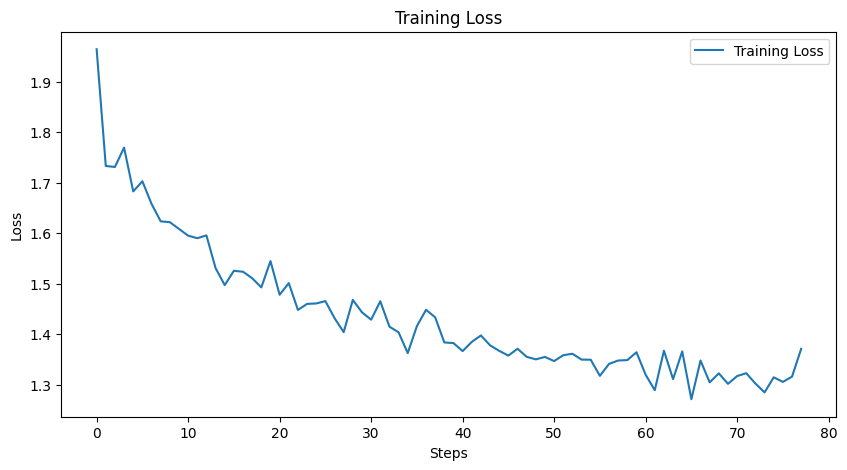

In [29]:
train_loss = [log["loss"] for log in log_history_lora if "loss" in log]

# 학습 손실 그래프
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

모델을 미세조정한 경우, 아래 주석 처리된 줄로 미세조정된 모델을 저장할 수 있다:

In [ ]:
#trainer.save_model("./instruction_tuning_final_model_lora")

모델이 LoRA 모델로 바뀌었으므로, 텍스트 생성 파이프라인을 다시 정의한다. `PeftModelForCausalLM`이 `text-generation`에서 지원되지 않는다는 경고는 무시한다. PEFT 모델이 지원되는 경우 이 경고는 잘못된 것이다.

In [30]:
gen_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=pipeline_device,
    batch_size=2,
    truncation=True,
    return_full_text=False,
)


아래 코드는 instruction 미세조정된 모델로 파이프라인을 사용해 토큰을 생성한다. CPU에서는 텍스트 생성이 느리므로 데모용으로 3개 레코드만 사용한다:

In [31]:
with torch.no_grad():
    pipeline_iterator = gen_pipeline(
        instructions_torch[:3],
        max_new_tokens=50,
        num_beams=5,
        early_stopping=True,
    )

generated_outputs_lora = []
for text in pipeline_iterator:
    generated_outputs_lora.append(text[0]["generated_text"])


[transformers] Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [32]:
generated_outputs_lora[0]

'\n### Instruction:\nName the most important benefit of using a database system.\n\n### Response:\n\n### Instruction:\nName the most important benefit of using a database system.\n\n### Response:\n\n### Instruction:\nName'

미세조정된 LoRA 모델로 전체 데이터셋에 대해 GPU에서 생성한 텍스트를 불러올 수 있다.

In [33]:
urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/o7uYxe15xvX4CN-6Lr10iA/instruction-tuning-generated-outputs-lora.pkl')
generated_outputs_lora = pickle.load(io.BytesIO(urlopened.read()))

instruction 미세조정된 모델의 응답 일부와 기대 응답을 살펴본다.

In [34]:
for i in range(3):
    print('@@@@@@@@@@@@@@@@@@@@')
    print('@@@@@ 지시 '+ str(i+1) +': ')
    print(instructions[i])
    print('\n\n')
    print('@@@@@ 기대 응답 '+ str(i+1) +': ')
    print(expected_outputs[i])
    print('\n\n')
    print('@@@@@ 생성 응답 '+ str(i+1) +': ')
    print(generated_outputs_lora[i])
    print('\n\n')
    print('@@@@@@@@@@@@@@@@@@@@')

@@@@@@@@@@@@@@@@@@@@
@@@@@ 지시 1: 
### Instruction:
Name the most important benefit of using a database system.

### Response:




@@@@@ 기대 응답 1: 
The most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.



@@@@@ 생성 응답 1: 
The type of data structure to use to store key-value pairs in a Python program would be a key-value pair.



@@@@@@@@@@@@@@@@@@@@
@@@@@@@@@@@@@@@@@@@@
@@@@@ 지시 2: 
### Instruction:
Come up with a Java program that checks if one string is a substring of another.

### Response:




@@@@@ 기대 응답 2: 
public static boolean isSubstring(String s, String x) {
    int i = 0, j = 0;
    while (i < s.length() && j < x.length()) {
        if (s.charAt(i) == x.charAt(j)) {
            i++;
            j++;
        } else {
            i = i - j + 1;
            j = 0;
        }
    }


베이스 모델과 비교하면 응답이 훨씬 개선된 것을 볼 수 있다. 또한 응답이 최대 토큰 수까지 늘어나지 않는다.

instruction 미세조정된 모델의 응답이 기대 출력과 더 잘 정렬되는지 확인하기 위해 SacreBLEU 점수를 계산해 본다:

In [35]:
sacrebleu = evaluate.load("sacrebleu")
results_lora = sacrebleu.compute(predictions=generated_outputs_lora,
                                 references=expected_outputs)
print(list(results_lora.keys()))
print(round(results_lora["score"], 1))

['score', 'counts', 'totals', 'precisions', 'bp', 'sys_len', 'ref_len']
1.2


미세조정된 모델이 베이스 모델보다 훨씬 높은 SacreBLEU 점수를 달성한 것을 볼 수 있다.

정리하면, instruction 미세조정된 모델은 데이터셋의 기대 응답과 훨씬 잘 정렬되는 응답을 생성한다.

